# Analisis de Electricidad y Magnetismo

**Materia:** Machine Learning 1  
**Tema:** prediccion y analisis del rendimiento academico en la asignatura `ELECTRICIDAD Y MAGNETISMO`.

Este notebook usa como base `datos_concatenados.csv` y como guia de estilo el repositorio de la catedra `https://github.com/carlobeni/Machine-Learning.git`, especialmente el TP2 de preprocesamiento y regresion logistica.

El objetivo es responder estas preguntas:

- Cual fue el problema abordado y que preguntas se plantearon.
- Que tipo de problema de ML se aborda.
- Que modelos se usaron.
- Que metricas se usaron.
- Si un estudiante pasa o no pasa Electricidad y Magnetismo.
- Que carrera se ve mas afectada.
- Que correlacion existe con otras materias.
- Como cambian esas correlaciones en diferentes carreras.
- Que se puede analizar despues del primer parcial y que informacion no debe usarse todavia.

## Respuesta conceptual inicial

El problema abordado consiste en analizar el desempeno academico de los estudiantes en la asignatura **Electricidad y Magnetismo**, comparando resultados entre carreras y estudiando su relacion con otras materias. El objetivo principal es predecir, despues del primer parcial, si un estudiante aprobara o no aprobara la asignatura.

El tipo de problema principal es **clasificacion binaria supervisada**, porque se predice una variable con dos clases:

- `1`: aprueba Electricidad y Magnetismo.
- `0`: no aprueba Electricidad y Magnetismo.

Adicionalmente se realiza **analisis exploratorio** y **analisis de correlacion** para estudiar diferencias por carrera y relacion con otras materias. Como complemento, tambien podria plantearse una regresion para estimar nota final numerica, pero el enfoque principal de este notebook es aprobar/no aprobar.

## Preguntas planteadas

Las preguntas que guian el analisis son:

1. Cual es la tasa de aprobacion de Electricidad y Magnetismo.
2. Que carreras tienen mayor y menor aprobacion en esta asignatura.
3. Despues del primer parcial, se puede anticipar si el estudiante aprobara o no.
4. Que variables disponibles despues del primer parcial explican mejor el resultado.
5. Que relacion existe entre aprobar Electricidad y Magnetismo y el rendimiento previo en otras materias.
6. Las correlaciones con otras materias cambian segun la carrera.
7. Que metricas permiten evaluar correctamente el modelo.

In [1]:
# Instalar dependencias faltantes si el entorno no las tiene.
import importlib.util
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
}

missing = [
    package
    for module, package in required_packages.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    print("Instalando dependencias faltantes:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Dependencias principales disponibles.")

Dependencias principales disponibles.


In [2]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
RANDOM_STATE = 42
SUBJECT_NAME = "ELECTRICIDAD Y MAGNETISMO"

## 1. Carga de datos y limpieza del dataframe

Se carga el CSV completo, pero se conservan solamente las columnas necesarias para este analisis. Esto deja el dataframe mas claro y evita trabajar con variables administrativas que no aportan al problema.

In [3]:
csv_path = Path("datos_concatenados.csv")

if not csv_path.exists():
    raise FileNotFoundError("No se encontro datos_concatenados.csv en la carpeta del notebook.")

df_raw = pd.read_csv(csv_path)
print(f"Dataset original: {df_raw.shape[0]:,} filas y {df_raw.shape[1]:,} columnas.")

columnas_necesarias = [
    "ALUMNO_ID",
    "Cod.Asign",
    "Asignatura",
    "Cod.Car.Sec",
    "Cod.Curso",
    "Convocatoria",
    "Anho",
    "Semestre",
    "Aprobado",
    "Primer.Par",
    "Segundo.Par",
    "TPLab.",
    "Lab.",
    "Proy.",
    "Pond.PP",
    "Pond.SP",
    "Pond.TPLab",
    "Pond.Lab",
    "Pond.Proy",
    "Asis",
    "Requisito",
    "Firma",
    "Primer.Rec",
    "Segundo.Rec",
    "Nota.Final",
    "FirmaCalculada",
]

columnas_existentes = [col for col in columnas_necesarias if col in df_raw.columns]
df = df_raw[columnas_existentes].copy()

print(f"Dataset reducido: {df.shape[0]:,} filas y {df.shape[1]:,} columnas.")
display(df.head())

Dataset original: 72,740 filas y 31 columnas.
Dataset reducido: 72,740 filas y 26 columnas.


,ALUMNO_ID,Cod.Asign,Asignatura,Cod.Car.Sec,Cod.Curso,Convocatoria,Anho,Semestre,Aprobado,Primer.Par,Segundo.Par,TPLab.,Lab.,Proy.,Pond.PP,Pond.SP,Pond.TPLab,Pond.Lab,Pond.Proy,Asis,Requisito,Firma,Primer.Rec,Segundo.Rec,Nota.Final,FirmaCalculada
0,FIUNA_ALUMNO_005925,13012,FISICA 3,CGF-PLS13,3,2,2024,2,N,33,43,40,100,0,40,40,10,10,0,1,1,0.0,28,0,NaN,NaN
1,FIUNA_ALUMNO_007516,13012,FISICA 3,CGF-PLS13,3,2,2024,2,N,33,43,40,100,0,40,40,10,10,0,1,1,0.0,28,0,NaN,NaN
2,FIUNA_ALUMNO_005493,13012,FISICA 3,ELE-PLS13,3,2,2024,2,N,5,10,20,80,0,40,40,10,10,0,1,0,0.0,0,0,NaN,NaN
3,FIUNA_ALUMNO_007517,13012,FISICA 3,ELE-PLS13,3,2,2024,2,N,5,10,20,80,0,40,40,10,10,0,1,0,0.0,0,0,NaN,NaN
4,FIUNA_ALUMNO_006375,13012,FISICA 3,CIV-PLS13,3,2,2024,2,N,30,30,50,100,0,40,40,10,10,0,1,1,0.0,14,0,NaN,NaN


In [4]:
career_code_mapping = {
    "CIV-PLS13": "Ing. Civil",
    "CIV-PLS23": "Ing. Civil",
    "INT9CONSTR": "Ing. Civil",
    "INT9TRANSP": "Ing. Civil",
    "INT9ORTERR": "Ing. Civil",
    "INT9SANEHI": "Ing. Civil",

    "ELE-PLS13": "Ing. Electronica",
    "ELE-PLS23": "Ing. Electronica",
    "INT9ELECTR": "Ing. Electronica",
    "INT9SDIGYT": "Ing. Electronica",

    "MCT-PLS13": "Ing. Mecatronica",
    "MCT-PLS23": "Ing. Mecatronica",
    "MCT9-OPT": "Ing. Mecatronica",

    "IND-PLS13": "Ing. Industrial",
    "IND-PLS23": "Ing. Industrial",
    "INT9G-ECO": "Ing. Industrial",
    "INT9-PROYT": "Ing. Industrial",

    "CGF-PLS13": "Ing. Geografica",
    "CGF-PLS23": "Ing. Geografica",
    "INT9RNYMA": "Ing. Geografica",

    "MEC-PLS13": "Ing. Mecanica",
    "MEC-PLS23": "Ing. Mecanica",
    "INT9MECANI": "Ing. Mecanica",
    "MEC9-OPT": "Ing. Mecanica",

    "ECA-PLS13": "Ing. Electromecanica",
    "ECA-PLS23": "Ing. Electromecanica",
    "ECA9-OPT": "Ing. Electromecanica",
}

def clean_numeric(series, lower=None, upper=None):
    values = pd.to_numeric(series, errors="coerce")
    if lower is not None:
        values = values.where(values >= lower)
    if upper is not None:
        values = values.where(values <= upper)
    return values

def parse_nota_final(value):
    if pd.isna(value):
        return np.nan
    matches = re.findall(r"(\d+)F-(\d+)", str(value))
    if not matches:
        return np.nan
    final_number, grade = max((int(f), int(g)) for f, g in matches)
    return grade

df_clean = df.copy()

text_cols = ["ALUMNO_ID", "Cod.Asign", "Asignatura", "Cod.Car.Sec", "Aprobado", "Nota.Final"]
for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype("string").str.strip()

df_clean["Asignatura_Normalizada"] = df_clean["Asignatura"].str.upper()
df_clean["Cod.Car.Sec"] = df_clean["Cod.Car.Sec"].str.strip()
df_clean["Carrera_Nombre"] = df_clean["Cod.Car.Sec"].map(career_code_mapping)
df_clean["Target"] = df_clean["Aprobado"].str.upper().map({"S": 1, "N": 0})

numeric_ranges = {
    "Primer.Par": (0, 100),
    "Segundo.Par": (0, 100),
    "TPLab.": (0, 100),
    "Lab.": (0, 100),
    "Proy.": (0, 100),
    "Pond.PP": (0, 100),
    "Pond.SP": (0, 100),
    "Pond.TPLab": (0, 100),
    "Pond.Lab": (0, 100),
    "Pond.Proy": (0, 100),
    "Asis": (0, 2),
    "Requisito": (0, 1),
    "Firma": (0, 100),
    "Primer.Rec": (0, 100),
    "Segundo.Rec": (0, 100),
    "FirmaCalculada": (0, 100),
    "Cod.Curso": (None, None),
    "Convocatoria": (None, None),
    "Anho": (None, None),
    "Semestre": (None, None),
}

for col, (lower, upper) in numeric_ranges.items():
    if col in df_clean.columns:
        df_clean[col] = clean_numeric(df_clean[col], lower, upper)

df_clean["Primer_Par_Clean"] = df_clean["Primer.Par"]
df_clean["Segundo_Par_Clean"] = df_clean["Segundo.Par"]
df_clean["TPLab_Clean"] = df_clean["TPLab."]
df_clean["Lab_Clean"] = df_clean["Lab."]
df_clean["Proy_Clean"] = df_clean["Proy."]
df_clean["Asis_Clean"] = df_clean["Asis"]
df_clean["Requisito_Clean"] = df_clean["Requisito"]
df_clean["Firma_Clean"] = df_clean["Firma"]
df_clean["Primer_Rec_Clean"] = df_clean["Primer.Rec"]
df_clean["FirmaCalc_Clean"] = df_clean["FirmaCalculada"]

df_clean["Score_Parciales"] = (
    df_clean["Primer_Par_Clean"].fillna(0) + df_clean["Segundo_Par_Clean"].fillna(0)
) / 2.0
df_clean["Diff_Parciales"] = (
    df_clean["Segundo_Par_Clean"].fillna(0) - df_clean["Primer_Par_Clean"].fillna(0)
)
df_clean["Nota_Final_Num"] = df_clean["Nota.Final"].map(parse_nota_final)
df_clean["Periodo_Orden"] = df_clean["Anho"].astype("Int64") * 10 + df_clean["Semestre"].astype("Int64")
df_clean["Periodo"] = df_clean["Anho"].astype("Int64").astype(str) + "-" + df_clean["Semestre"].astype("Int64").astype(str)

before = len(df_clean)
df_clean = df_clean.dropna(subset=["ALUMNO_ID", "Asignatura_Normalizada", "Carrera_Nombre", "Target", "Periodo_Orden"]).copy()
after = len(df_clean)

print(f"Filas antes de quitar registros sin campos esenciales: {before:,}")
print(f"Filas despues de limpieza esencial: {after:,}")
print(f"Retencion: {100 * after / before:.2f}%")
display(df_clean.head())

Filas antes de quitar registros sin campos esenciales: 72,740
Filas despues de limpieza esencial: 72,735
Retencion: 99.99%


,ALUMNO_ID,Cod.Asign,Asignatura,Cod.Car.Sec,Cod.Curso,Convocatoria,Anho,Semestre,Aprobado,Primer.Par,Segundo.Par,TPLab.,Lab.,Proy.,Pond.PP,Pond.SP,Pond.TPLab,Pond.Lab,Pond.Proy,Asis,Requisito,Firma,Primer.Rec,Segundo.Rec,Nota.Final,FirmaCalculada,Asignatura_Normalizada,Carrera_Nombre,Target,Primer_Par_Clean,Segundo_Par_Clean,TPLab_Clean,Lab_Clean,Proy_Clean,Asis_Clean,Requisito_Clean,Firma_Clean,Primer_Rec_Clean,FirmaCalc_Clean,Score_Parciales,Diff_Parciales,Nota_Final_Num,Periodo_Orden,Periodo
0,FIUNA_ALUMNO_005925,13012,FISICA 3,CGF-PLS13,3,2,2024,2,N,33,43,40,100,0,40,40,10,10,0,1,1,0.0,28,0,<NA>,NaN,FISICA 3,Ing. Geografica,0,33,43,40,100,0,1,1,0.0,28,NaN,38.0,10,NaN,20242,2024-2
1,FIUNA_ALUMNO_007516,13012,FISICA 3,CGF-PLS13,3,2,2024,2,N,33,43,40,100,0,40,40,10,10,0,1,1,0.0,28,0,<NA>,NaN,FISICA 3,Ing. Geografica,0,33,43,40,100,0,1,1,0.0,28,NaN,38.0,10,NaN,20242,2024-2
2,FIUNA_ALUMNO_005493,13012,FISICA 3,ELE-PLS13,3,2,2024,2,N,5,10,20,80,0,40,40,10,10,0,1,0,0.0,0,0,<NA>,NaN,FISICA 3,Ing. Electronica,0,5,10,20,80,0,1,0,0.0,0,NaN,7.5,5,NaN,20242,2024-2
3,FIUNA_ALUMNO_007517,13012,FISICA 3,ELE-PLS13,3,2,2024,2,N,5,10,20,80,0,40,40,10,10,0,1,0,0.0,0,0,<NA>,NaN,FISICA 3,Ing. Electronica,0,5,10,20,80,0,1,0,0.0,0,NaN,7.5,5,NaN,20242,2024-2
4,FIUNA_ALUMNO_006375,13012,FISICA 3,CIV-PLS13,3,2,2024,2,N,30,30,50,100,0,40,40,10,10,0,1,1,0.0,14,0,<NA>,NaN,FISICA 3,Ing. Civil,0,30,30,50,100,0,1,1,0.0,14,NaN,30.0,0,NaN,20242,2024-2


## 2. Filtrado de Electricidad y Magnetismo

A partir del dataframe limpio se filtra la asignatura de interes. El resto de materias se conserva solamente para calcular historial y correlaciones.

In [6]:
df_eym = df_clean[df_clean["Asignatura_Normalizada"] == SUBJECT_NAME].copy()

print(f"Registros de {SUBJECT_NAME}: {len(df_eym):,}")
print(f"Alumnos unicos en la asignatura: {df_eym['ALUMNO_ID'].nunique():,}")
display(df_eym[[
    "ALUMNO_ID",
    "Asignatura",
    "Carrera_Nombre",
    "Anho",
    "Semestre",
    "Primer_Par_Clean",
    "Segundo_Par_Clean",
    "Firma_Clean",
    "Aprobado",
    "Target",
]].head())

Registros de ELECTRICIDAD Y MAGNETISMO: 1,606
Alumnos unicos en la asignatura: 1,337


,ALUMNO_ID,Asignatura,Carrera_Nombre,Anho,Semestre,Primer_Par_Clean,Segundo_Par_Clean,Firma_Clean,Aprobado,Target
18302,FIUNA_ALUMNO_000452,ELECTRICIDAD Y MAGNETISMO,Ing. Civil,2024,2,4,0,0.0,N,0
18303,FIUNA_ALUMNO_012722,ELECTRICIDAD Y MAGNETISMO,Ing. Civil,2024,2,4,0,0.0,N,0
18304,FIUNA_ALUMNO_003750,ELECTRICIDAD Y MAGNETISMO,Ing. Mecanica,2024,2,28,18,0.0,N,0
18305,FIUNA_ALUMNO_004171,ELECTRICIDAD Y MAGNETISMO,Ing. Mecanica,2024,2,28,18,0.0,N,0
18306,FIUNA_ALUMNO_005168,ELECTRICIDAD Y MAGNETISMO,Ing. Industrial,2024,2,23,0,0.0,N,0


,registros,alumnos_unicos,carreras,periodos,aprobados,no_aprobados,tasa_aprobacion,tasa_no_aprobacion
0,1606,1337,7,3,338,1268,21.05%,78.95%


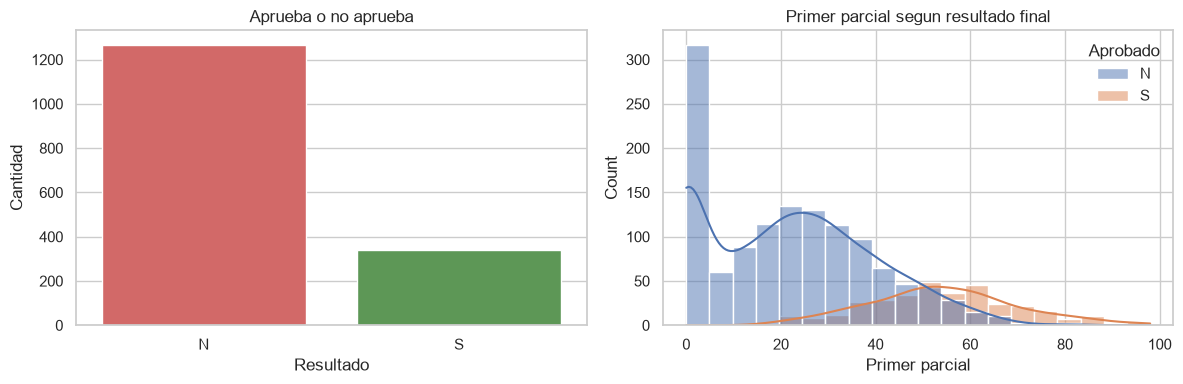

In [7]:
resumen_eym = pd.DataFrame({
    "registros": [len(df_eym)],
    "alumnos_unicos": [df_eym["ALUMNO_ID"].nunique()],
    "carreras": [df_eym["Carrera_Nombre"].nunique()],
    "periodos": [df_eym["Periodo"].nunique()],
    "aprobados": [int(df_eym["Target"].sum())],
    "no_aprobados": [int((1 - df_eym["Target"]).sum())],
    "tasa_aprobacion": [df_eym["Target"].mean()],
    "tasa_no_aprobacion": [1 - df_eym["Target"].mean()],
})

display(resumen_eym.style.format({
    "tasa_aprobacion": "{:.2%}",
    "tasa_no_aprobacion": "{:.2%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_eym, x="Aprobado", order=["N", "S"], ax=axes[0], palette=["#E45756", "#54A24B"])
axes[0].set_title("Aprueba o no aprueba")
axes[0].set_xlabel("Resultado")
axes[0].set_ylabel("Cantidad")

sns.histplot(data=df_eym, x="Primer_Par_Clean", hue="Aprobado", bins=20, kde=True, ax=axes[1])
axes[1].set_title("Primer parcial segun resultado final")
axes[1].set_xlabel("Primer parcial")

plt.tight_layout()
plt.show()

## 3. Carrera mas afectada

Para identificar que carrera se ve mas afectada, se compara la tasa de no aprobacion por carrera. La carrera mas afectada es la que presenta mayor proporcion de estudiantes que no aprueban Electricidad y Magnetismo.

In [8]:
carrera_impacto = (
    df_eym.groupby("Carrera_Nombre")
    .agg(
        registros=("Target", "size"),
        aprobados=("Target", "sum"),
        tasa_aprobacion=("Target", "mean"),
        promedio_primer_parcial=("Primer_Par_Clean", "mean"),
        mediana_primer_parcial=("Primer_Par_Clean", "median"),
    )
    .sort_values("tasa_aprobacion")
)

carrera_impacto["no_aprobados"] = carrera_impacto["registros"] - carrera_impacto["aprobados"]
carrera_impacto["tasa_no_aprobacion"] = 1 - carrera_impacto["tasa_aprobacion"]
carrera_impacto["diferencia_vs_promedio_global"] = carrera_impacto["tasa_aprobacion"] - df_eym["Target"].mean()

display(carrera_impacto[[
    "registros",
    "aprobados",
    "no_aprobados",
    "tasa_aprobacion",
    "tasa_no_aprobacion",
    "diferencia_vs_promedio_global",
    "promedio_primer_parcial",
    "mediana_primer_parcial",
]].style.format({
    "tasa_aprobacion": "{:.2%}",
    "tasa_no_aprobacion": "{:.2%}",
    "diferencia_vs_promedio_global": "{:+.2%}",
    "promedio_primer_parcial": "{:.2f}",
    "mediana_primer_parcial": "{:.2f}",
}))

carrera_mas_afectada = carrera_impacto["tasa_no_aprobacion"].idxmax()
print("Carrera mas afectada segun tasa de no aprobacion:", carrera_mas_afectada)

,registros,aprobados,no_aprobados,tasa_aprobacion,tasa_no_aprobacion,diferencia_vs_promedio_global,promedio_primer_parcial,mediana_primer_parcial
Carrera_Nombre,,,,,,,,
Ing. Geografica,79,5,74,6.33%,93.67%,-14.72%,16.19,12.00
Ing. Mecanica,70,5,65,7.14%,92.86%,-13.90%,23.53,25.00
Ing. Electronica,313,64,249,20.45%,79.55%,-0.60%,26.96,25.00
Ing. Civil,751,162,589,21.57%,78.43%,+0.53%,29.73,28.00
Ing. Industrial,162,36,126,22.22%,77.78%,+1.18%,30.28,31.00
Ing. Mecatronica,179,49,130,27.37%,72.63%,+6.33%,30.65,27.00
Ing. Electromecanica,52,17,35,32.69%,67.31%,+11.65%,35.71,30.00


Carrera mas afectada segun tasa de no aprobacion: Ing. Geografica


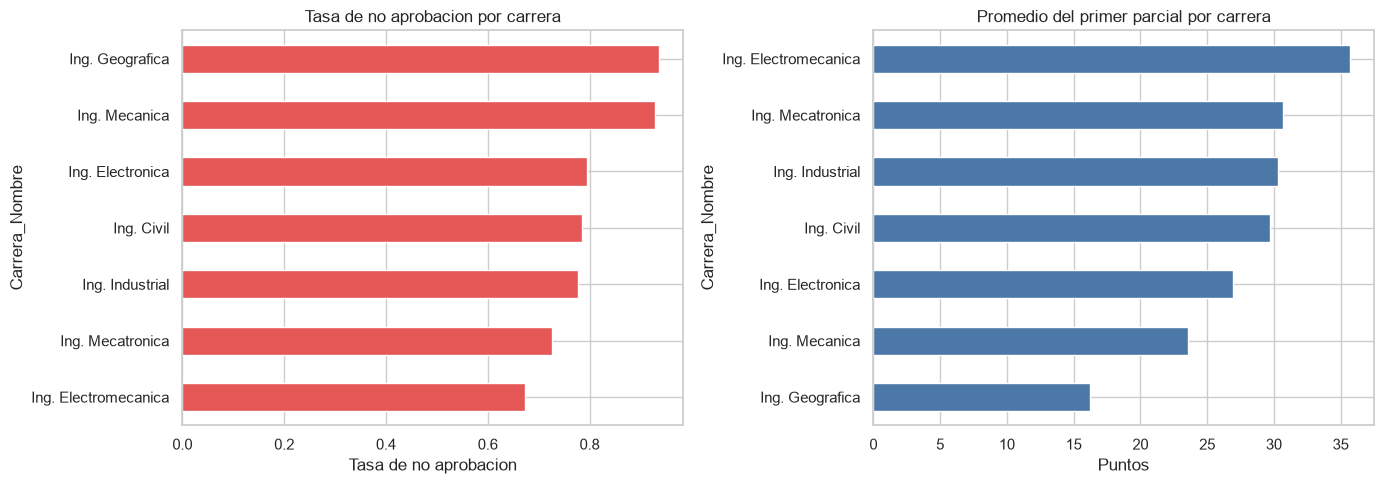

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

carrera_impacto.sort_values("tasa_no_aprobacion")["tasa_no_aprobacion"].plot(
    kind="barh",
    ax=axes[0],
    color="#E45756",
)
axes[0].set_title("Tasa de no aprobacion por carrera")
axes[0].set_xlabel("Tasa de no aprobacion")

carrera_impacto.sort_values("promedio_primer_parcial")["promedio_primer_parcial"].plot(
    kind="barh",
    ax=axes[1],
    color="#4C78A8",
)
axes[1].set_title("Promedio del primer parcial por carrera")
axes[1].set_xlabel("Puntos")

plt.tight_layout()
plt.show()

## 4. Feature engineering sin fuga de informacion

Como el analisis se plantea **despues del primer parcial**, no se deben usar variables que ocurren despues, como segundo parcial, firma, recuperatorios, nota final o el propio resultado final como entrada del modelo.

En esta seccion se crean variables historicas usando solo periodos anteriores del estudiante.

In [10]:
# Historial del alumno antes del periodo actual.
student_period = (
    df_clean.groupby(["ALUMNO_ID", "Periodo_Orden"], as_index=False)
    .agg(
        registros_periodo=("Target", "size"),
        aprobados_periodo=("Target", "sum"),
        primer_sum_periodo=("Primer_Par_Clean", "sum"),
        primer_count_periodo=("Primer_Par_Clean", "count"),
        score_sum_periodo=("Score_Parciales", "sum"),
        score_count_periodo=("Score_Parciales", "count"),
    )
    .sort_values(["ALUMNO_ID", "Periodo_Orden"])
)

g = student_period.groupby("ALUMNO_ID", sort=False)
student_period["hist_registros_previos"] = g["registros_periodo"].cumsum() - student_period["registros_periodo"]
student_period["hist_aprobados_previos"] = g["aprobados_periodo"].cumsum() - student_period["aprobados_periodo"]
student_period["hist_primer_sum_previo"] = g["primer_sum_periodo"].cumsum() - student_period["primer_sum_periodo"]
student_period["hist_primer_count_previo"] = g["primer_count_periodo"].cumsum() - student_period["primer_count_periodo"]
student_period["hist_score_sum_previo"] = g["score_sum_periodo"].cumsum() - student_period["score_sum_periodo"]
student_period["hist_score_count_previo"] = g["score_count_periodo"].cumsum() - student_period["score_count_periodo"]

student_period["Hist_Tasa_Aprobacion"] = (
    student_period["hist_aprobados_previos"] / student_period["hist_registros_previos"].replace(0, np.nan)
)
student_period["Hist_Primer_Par_Mean"] = (
    student_period["hist_primer_sum_previo"] / student_period["hist_primer_count_previo"].replace(0, np.nan)
)
student_period["Hist_Score_Parciales_Mean"] = (
    student_period["hist_score_sum_previo"] / student_period["hist_score_count_previo"].replace(0, np.nan)
)
student_period["Hist_Cantidad_Materias"] = student_period["hist_registros_previos"]
student_period["Sin_Historial"] = (student_period["hist_registros_previos"] == 0).astype(int)

# Carga academica en el periodo actual. Es informacion de inscripcion, por eso puede conocerse temprano.
carga_periodo = (
    df_clean.groupby(["ALUMNO_ID", "Periodo_Orden"], as_index=False)
    .agg(Carga_Materias_Periodo=("Cod.Asign", "nunique"))
)

# Dificultad historica de la asignatura antes del periodo actual.
subject_period = (
    df_clean.groupby(["Asignatura_Normalizada", "Periodo_Orden"], as_index=False)
    .agg(aprobados_periodo=("Target", "sum"), registros_periodo=("Target", "size"))
    .sort_values(["Asignatura_Normalizada", "Periodo_Orden"])
)

g_subject = subject_period.groupby("Asignatura_Normalizada", sort=False)
subject_period["aprobados_previos"] = g_subject["aprobados_periodo"].cumsum() - subject_period["aprobados_periodo"]
subject_period["registros_previos"] = g_subject["registros_periodo"].cumsum() - subject_period["registros_periodo"]
subject_period["Dificultad_Asignatura_Previa"] = 1 - (
    subject_period["aprobados_previos"] / subject_period["registros_previos"].replace(0, np.nan)
)

df_eym_model = df_eym.merge(
    student_period[[
        "ALUMNO_ID",
        "Periodo_Orden",
        "Hist_Tasa_Aprobacion",
        "Hist_Primer_Par_Mean",
        "Hist_Score_Parciales_Mean",
        "Hist_Cantidad_Materias",
        "Sin_Historial",
    ]],
    on=["ALUMNO_ID", "Periodo_Orden"],
    how="left",
)

df_eym_model = df_eym_model.merge(
    carga_periodo,
    on=["ALUMNO_ID", "Periodo_Orden"],
    how="left",
)

df_eym_model = df_eym_model.merge(
    subject_period[["Asignatura_Normalizada", "Periodo_Orden", "Dificultad_Asignatura_Previa"]],
    on=["Asignatura_Normalizada", "Periodo_Orden"],
    how="left",
)

display(df_eym_model[[
    "ALUMNO_ID",
    "Carrera_Nombre",
    "Periodo",
    "Primer_Par_Clean",
    "Hist_Tasa_Aprobacion",
    "Hist_Primer_Par_Mean",
    "Hist_Cantidad_Materias",
    "Carga_Materias_Periodo",
    "Dificultad_Asignatura_Previa",
    "Target",
]].head())

,ALUMNO_ID,Carrera_Nombre,Periodo,Primer_Par_Clean,Hist_Tasa_Aprobacion,Hist_Primer_Par_Mean,Hist_Cantidad_Materias,Carga_Materias_Periodo,Dificultad_Asignatura_Previa,Target
0,FIUNA_ALUMNO_000452,Ing. Civil,2024-2,4,NaN,NaN,0,5,NaN,0
1,FIUNA_ALUMNO_012722,Ing. Civil,2024-2,4,NaN,NaN,0,5,NaN,0
2,FIUNA_ALUMNO_003750,Ing. Mecanica,2024-2,28,NaN,NaN,0,2,NaN,0
3,FIUNA_ALUMNO_004171,Ing. Mecanica,2024-2,28,NaN,NaN,0,2,NaN,0
4,FIUNA_ALUMNO_005168,Ing. Industrial,2024-2,23,NaN,NaN,0,5,NaN,0


In [11]:
variables_disponibilidad = pd.DataFrame({
    "variable": [
        "Carrera_Nombre",
        "Cod.Curso",
        "Anho",
        "Semestre",
        "Primer_Par_Clean",
        "Asis_Clean",
        "Hist_Tasa_Aprobacion",
        "Hist_Primer_Par_Mean",
        "Hist_Cantidad_Materias",
        "Carga_Materias_Periodo",
        "Dificultad_Asignatura_Previa",
        "Segundo_Par_Clean",
        "Firma_Clean",
        "Primer_Rec_Clean",
        "Nota_Final_Num",
        "Target",
    ],
    "usar_despues_primer_parcial": [
        "si",
        "si",
        "si",
        "si",
        "si",
        "si, si ya esta disponible",
        "si",
        "si",
        "si",
        "si",
        "si",
        "no",
        "no",
        "no",
        "no",
        "solo como variable objetivo, no como entrada",
    ],
    "motivo": [
        "Dato conocido antes de cursar",
        "Dato curricular conocido",
        "Dato del periodo",
        "Dato del periodo",
        "Resultado disponible despues del primer parcial",
        "Puede estar disponible parcialmente",
        "Historial anterior",
        "Historial anterior",
        "Historial anterior",
        "Carga de inscripcion del periodo",
        "Dificultad calculada con datos historicos",
        "Ocurre despues del primer parcial",
        "Resultado posterior de la cursada",
        "Ocurre despues de instancias posteriores",
        "Resultado final posterior",
        "Es lo que se quiere predecir",
    ],
})

display(variables_disponibilidad)

,variable,usar_despues_primer_parcial,motivo
0,Carrera_Nombre,si,Dato conocido antes de cursar
1,Cod.Curso,si,Dato curricular conocido
2,Anho,si,Dato del periodo
3,Semestre,si,Dato del periodo
4,Primer_Par_Clean,si,Resultado disponible despues del primer parcial
5,Asis_Clean,"si, si ya esta disponible",Puede estar disponible parcialmente
6,Hist_Tasa_Aprobacion,si,Historial anterior
7,Hist_Primer_Par_Mean,si,Historial anterior
8,Hist_Cantidad_Materias,si,Historial anterior
9,Carga_Materias_Periodo,si,Carga de inscripcion del periodo


## 5. Modelo utilizado: Regresion Logistica

La regresion logistica se usa porque el objetivo es predecir una probabilidad de aprobacion. Es un modelo adecuado para clasificacion binaria y permite interpretar el peso de las variables.

Se usa un pipeline con:

- Imputacion de nulos.
- Interacciones polinomiales de grado 2 para variables numericas.
- Escalado con `StandardScaler`.
- Codificacion `OneHotEncoder` para variables categoricas.
- `GridSearchCV` para ajustar el parametro `C`.

In [12]:
num_features = [
    "Primer_Par_Clean",
    "Asis_Clean",
    "Hist_Tasa_Aprobacion",
    "Hist_Primer_Par_Mean",
    "Hist_Score_Parciales_Mean",
    "Hist_Cantidad_Materias",
    "Sin_Historial",
    "Carga_Materias_Periodo",
    "Dificultad_Asignatura_Previa",
]

cat_features = [
    "Carrera_Nombre",
    "Cod.Curso",
    "Anho",
    "Semestre",
]

num_features = [col for col in num_features if col in df_eym_model.columns and df_eym_model[col].nunique(dropna=True) > 1]
cat_features = [col for col in cat_features if col in df_eym_model.columns and df_eym_model[col].nunique(dropna=True) > 1]

model_data = df_eym_model.dropna(subset=["Target"]).copy()

for col in cat_features:
    model_data[col] = model_data[col].astype("string")

X = model_data[num_features + cat_features].copy()
y = model_data["Target"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Variables numericas usadas:", num_features)
print("Variables categoricas usadas:", cat_features)
print("Train:", X_train.shape, "Test:", X_test.shape)
display(pd.DataFrame({
    "train_%": y_train.value_counts(normalize=True).mul(100).round(2),
    "test_%": y_test.value_counts(normalize=True).mul(100).round(2),
}).rename(index={0: "No aprueba", 1: "Aprueba"}))

Variables numericas usadas: ['Primer_Par_Clean', 'Asis_Clean', 'Hist_Tasa_Aprobacion', 'Hist_Primer_Par_Mean', 'Hist_Score_Parciales_Mean', 'Hist_Cantidad_Materias', 'Sin_Historial', 'Carga_Materias_Periodo', 'Dificultad_Asignatura_Previa']
Variables categoricas usadas: ['Carrera_Nombre', 'Anho', 'Semestre']
Train: (1284, 12) Test: (322, 12)


,train_%,test_%
Target,,
No aprueba,78.97,78.88
Aprueba,21.03,21.12


In [13]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", make_one_hot_encoder()),
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features),
])

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

param_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    logistic_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1,
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Mejor parametro:", grid_search.best_params_)
print("Mejor F1 promedio en validacion cruzada:", round(grid_search.best_score_, 4))
display(pd.DataFrame(grid_search.cv_results_)[["params", "mean_test_score", "std_test_score", "rank_test_score"]])

Mejor parametro: {'model__C': 10.0}
Mejor F1 promedio en validacion cruzada: 0.7119


,params,mean_test_score,std_test_score,rank_test_score
0,{'model__C': 0.01},0.695794,0.049319,4
1,{'model__C': 0.1},0.703434,0.050485,3
2,{'model__C': 1.0},0.705612,0.043502,2
3,{'model__C': 10.0},0.711884,0.037098,1


## 6. Metricas utilizadas

Para evaluar el modelo se usan metricas de clasificacion:

- **Accuracy:** proporcion total de predicciones correctas.
- **Precision:** de los que el modelo predice como aprobados, cuantos realmente aprueban.
- **Recall:** de los aprobados reales, cuantos detecta el modelo.
- **F1-score:** equilibrio entre precision y recall.
- **Matriz de confusion:** permite ver aciertos y tipos de error.
- **ROC-AUC:** mide capacidad de separar aprobados y no aprobados.
- **Precision-Recall / Average Precision:** util cuando hay desbalance.

In [14]:
y_proba_train = best_model.predict_proba(X_train)[:, 1]
y_proba_test = best_model.predict_proba(X_test)[:, 1]

threshold_grid = np.linspace(0.10, 0.90, 81)
threshold_table = pd.DataFrame({
    "threshold": threshold_grid,
    "precision_train": [precision_score(y_train, y_proba_train >= t, zero_division=0) for t in threshold_grid],
    "recall_train": [recall_score(y_train, y_proba_train >= t, zero_division=0) for t in threshold_grid],
    "f1_train": [f1_score(y_train, y_proba_train >= t, zero_division=0) for t in threshold_grid],
})

best_threshold = float(threshold_table.loc[threshold_table["f1_train"].idxmax(), "threshold"])
print("Umbral elegido segun F1 en entrenamiento:", round(best_threshold, 3))
display(threshold_table.sort_values("f1_train", ascending=False).head(10).round(4))

Umbral elegido segun F1 en entrenamiento: 0.62


,threshold,precision_train,recall_train,f1_train
52,0.62,0.6967,0.8593,0.7695
51,0.61,0.6893,0.8630,0.7664
50,0.60,0.6831,0.8704,0.7655
53,0.63,0.6930,0.8444,0.7613
49,0.59,0.6734,0.8704,0.7593
54,0.64,0.6944,0.8333,0.7576
48,0.58,0.6657,0.8704,0.7544
56,0.66,0.6984,0.8148,0.7521
55,0.65,0.6928,0.8185,0.7504
47,0.57,0.6574,0.8741,0.7504


In [15]:
y_pred_test = (y_proba_test >= best_threshold).astype(int)
y_pred_train = (y_proba_train >= best_threshold).astype(int)

metricas = pd.DataFrame([
    {
        "conjunto": "train",
        "accuracy": accuracy_score(y_train, y_pred_train),
        "precision": precision_score(y_train, y_pred_train, zero_division=0),
        "recall": recall_score(y_train, y_pred_train, zero_division=0),
        "f1": f1_score(y_train, y_pred_train, zero_division=0),
        "roc_auc": roc_auc_score(y_train, y_proba_train),
        "average_precision": average_precision_score(y_train, y_proba_train),
    },
    {
        "conjunto": "test",
        "accuracy": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(y_test, y_pred_test, zero_division=0),
        "recall": recall_score(y_test, y_pred_test, zero_division=0),
        "f1": f1_score(y_test, y_pred_test, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba_test),
        "average_precision": average_precision_score(y_test, y_proba_test),
    },
])

display(metricas.round(4))
print(classification_report(y_test, y_pred_test, target_names=["No aprueba", "Aprueba"], zero_division=0))

,conjunto,accuracy,precision,recall,f1,roc_auc,average_precision
0,train,0.8917,0.6967,0.8593,0.7695,0.9456,0.8156
1,test,0.8665,0.6316,0.8824,0.7362,0.9454,0.8250


              precision    recall  f1-score   support

  No aprueba       0.96      0.86      0.91       254
     Aprueba       0.63      0.88      0.74        68

    accuracy                           0.87       322
   macro avg       0.80      0.87      0.82       322
weighted avg       0.89      0.87      0.87       322



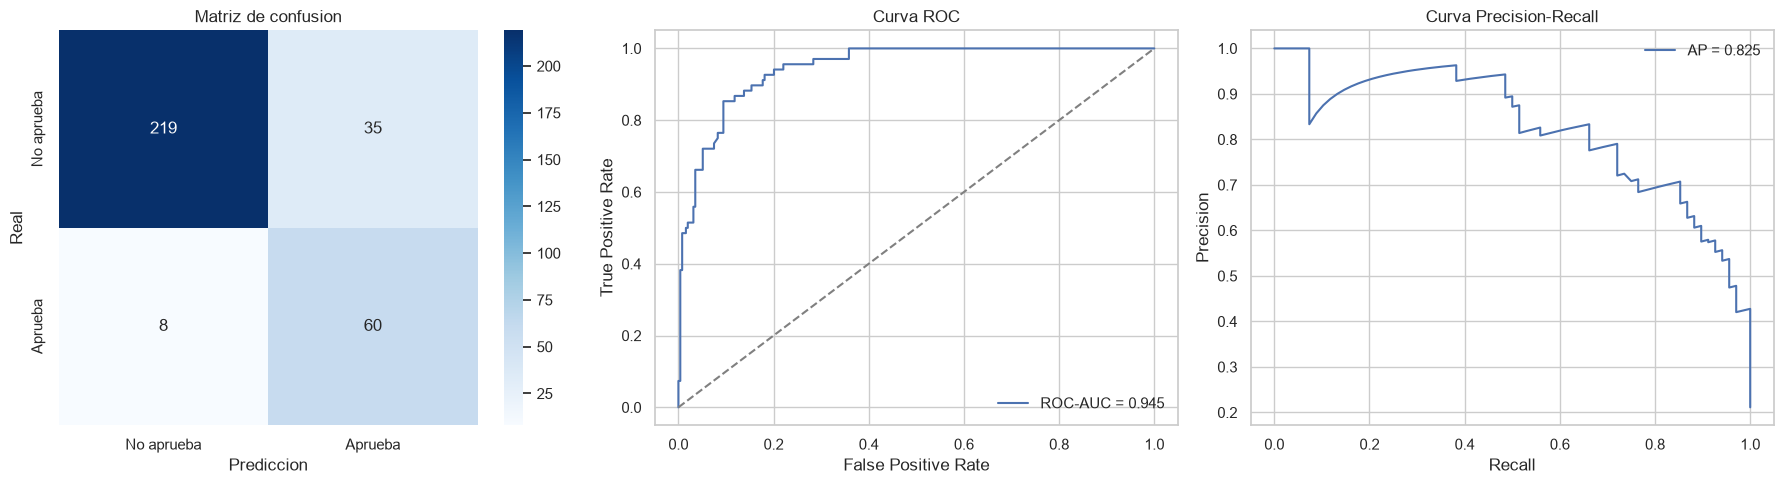

In [16]:
cm = confusion_matrix(y_test, y_pred_test)
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de confusion")
axes[0].set_xlabel("Prediccion")
axes[0].set_ylabel("Real")
axes[0].set_xticklabels(["No aprueba", "Aprueba"])
axes[0].set_yticklabels(["No aprueba", "Aprueba"])

axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba_test):.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Curva ROC")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

axes[2].plot(recall_curve, precision_curve, label=f"AP = {average_precision_score(y_test, y_proba_test):.3f}")
axes[2].set_title("Curva Precision-Recall")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()

plt.tight_layout()
plt.show()

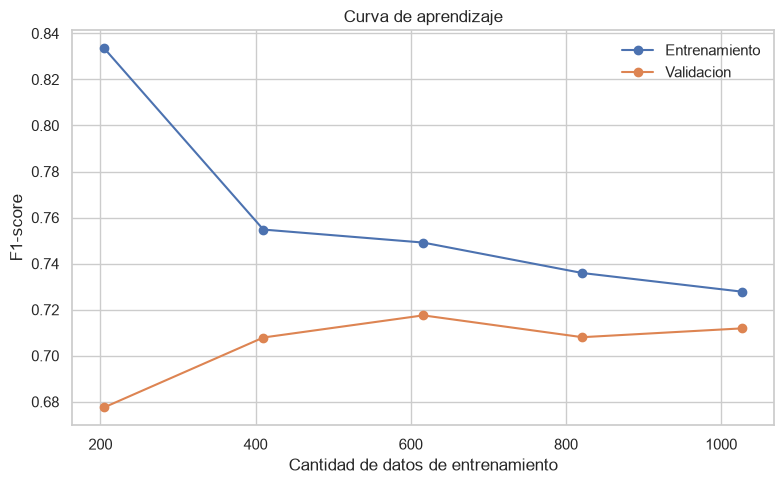

In [17]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=1,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Entrenamiento")
plt.plot(train_sizes, val_mean, marker="o", label="Validacion")
plt.title("Curva de aprendizaje")
plt.xlabel("Cantidad de datos de entrenamiento")
plt.ylabel("F1-score")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Interpretacion de variables y efecto de la carrera

Para analizar que variables influyen, se observan los coeficientes de la regresion logistica. Coeficientes positivos aumentan la probabilidad de aprobar; coeficientes negativos disminuyen esa probabilidad.

,variable,coeficiente,abs_coef
31,num__Hist_Tasa_Aprobacion Carga_Materias_Periodo,-3.617428,3.617428
37,num__Hist_Primer_Par_Mean Carga_Materias_Periodo,3.416408,3.416408
0,num__Primer_Par_Clean,3.024118,3.024118
18,num__Asis_Clean^2,-2.882244,2.882244
29,num__Hist_Tasa_Aprobacion Hist_Cantidad_Materias,2.500751,2.500751
27,num__Hist_Tasa_Aprobacion Hist_Primer_Par_Mean,-2.038417,2.038417
10,num__Primer_Par_Clean Asis_Clean,1.842876,1.842876
15,num__Primer_Par_Clean Sin_Historial,-1.761615,1.761615
12,num__Primer_Par_Clean Hist_Primer_Par_Mean,-1.757948,1.757948
17,num__Primer_Par_Clean Dificultad_Asignatura_Pr...,1.697260,1.697260


,variable,coeficiente,abs_coef
59,cat__Carrera_Nombre_Ing. Mecanica,-1.212831,1.212831
57,cat__Carrera_Nombre_Ing. Geografica,-0.583938,0.583938
54,cat__Carrera_Nombre_Ing. Civil,-0.463357,0.463357
58,cat__Carrera_Nombre_Ing. Industrial,-0.129290,0.129290
56,cat__Carrera_Nombre_Ing. Electronica,-0.051408,0.051408
60,cat__Carrera_Nombre_Ing. Mecatronica,0.843448,0.843448
55,cat__Carrera_Nombre_Ing. Electromecanica,0.997538,0.997538


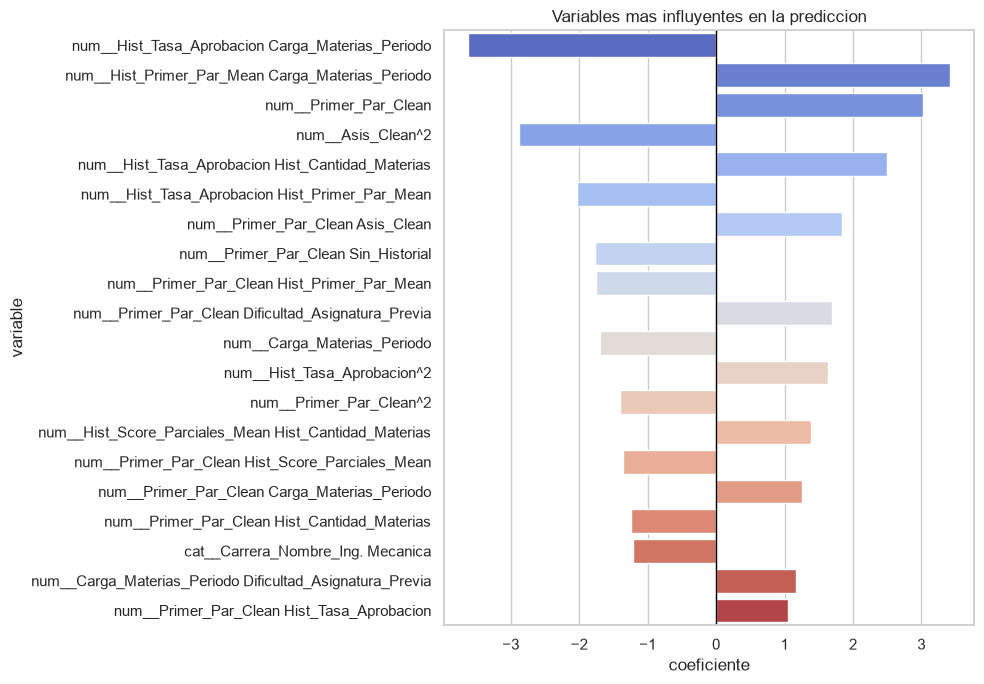

In [18]:
try:
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
except Exception:
    feature_names = np.array([f"feature_{i}" for i in range(best_model.named_steps["model"].coef_.shape[1])])

coefs = best_model.named_steps["model"].coef_[0]

coef_table = (
    pd.DataFrame({"variable": feature_names, "coeficiente": coefs})
    .assign(abs_coef=lambda x: x["coeficiente"].abs())
    .sort_values("abs_coef", ascending=False)
)

display(coef_table.head(30))

carrera_coefs = coef_table[coef_table["variable"].str.contains("Carrera_Nombre", regex=False)].copy()
display(carrera_coefs.sort_values("coeficiente"))

plt.figure(figsize=(10, 7))
sns.barplot(data=coef_table.head(20), y="variable", x="coeficiente", palette="coolwarm")
plt.axvline(0, color="black", linewidth=1)
plt.title("Variables mas influyentes en la prediccion")
plt.tight_layout()
plt.show()

## 8. Correlacion con otras materias

Esta parte responde que materias se relacionan con Electricidad y Magnetismo. Para evitar fuga de informacion, se usan materias cursadas en periodos anteriores al registro de Electricidad y Magnetismo.

Se calculan dos correlaciones:

- Correlacion entre aprobar otra materia y aprobar Electricidad y Magnetismo.
- Correlacion entre el score de parciales en otra materia y aprobar Electricidad y Magnetismo.

Cuando ambas variables son binarias, la correlacion de Pearson equivale a una correlacion tipo phi.

In [19]:
eym_events = df_eym_model[[
    "ALUMNO_ID",
    "Carrera_Nombre",
    "Periodo_Orden",
    "Target",
    "Primer_Par_Clean",
]].copy()
eym_events = eym_events.rename(columns={
    "Carrera_Nombre": "Carrera_EyM",
    "Periodo_Orden": "Periodo_EyM",
    "Target": "Target_EyM",
    "Primer_Par_Clean": "Primer_Par_EyM",
})

history = df_clean[[
    "ALUMNO_ID",
    "Carrera_Nombre",
    "Periodo_Orden",
    "Asignatura_Normalizada",
    "Asignatura",
    "Target",
    "Primer_Par_Clean",
    "Score_Parciales",
    "Nota_Final_Num",
]].copy()
history = history.rename(columns={
    "Carrera_Nombre": "Carrera_Otra",
    "Periodo_Orden": "Periodo_Otra",
    "Target": "Target_Otra",
    "Primer_Par_Clean": "Primer_Par_Otra",
    "Score_Parciales": "Score_Parciales_Otra",
})

corr_base = eym_events.merge(history, on="ALUMNO_ID", how="inner")
corr_base = corr_base[
    (corr_base["Periodo_Otra"] < corr_base["Periodo_EyM"])
    & (corr_base["Asignatura_Normalizada"] != SUBJECT_NAME)
].copy()

print("Registros historicos previos vinculados a Electricidad y Magnetismo:", len(corr_base))
display(corr_base.head())

Registros historicos previos vinculados a Electricidad y Magnetismo: 8520


,ALUMNO_ID,Carrera_EyM,Periodo_EyM,Target_EyM,Primer_Par_EyM,Carrera_Otra,Periodo_Otra,Asignatura_Normalizada,Asignatura,Target_Otra,Primer_Par_Otra,Score_Parciales_Otra,Nota_Final_Num
9282,FIUNA_ALUMNO_003750,Ing. Mecanica,20252,0,21,Ing. Mecanica,20242,TERMOTECNIA 1,TERMOTECNIA 1,0,27,37.0,NaN
9284,FIUNA_ALUMNO_003750,Ing. Mecanica,20252,0,21,Ing. Mecanica,20251,CALCULO 4,CALCULO 4,0,0,0.0,NaN
9285,FIUNA_ALUMNO_003750,Ing. Mecanica,20252,0,21,Ing. Mecanica,20251,DINAMICA,DINAMICA,0,20,25.0,NaN
9286,FIUNA_ALUMNO_003750,Ing. Mecanica,20252,0,21,Ing. Mecanica,20251,MECANICA DE MATERIALES 1,MECANICA DE MATERIALES 1,0,12,6.0,NaN
9287,FIUNA_ALUMNO_003750,Ing. Mecanica,20252,0,21,Ing. Mecanica,20251,FISICA 4,FISICA 4,0,28,24.0,NaN


In [20]:
def safe_corr(x, y, method="pearson", min_n=20):
    data = pd.concat([x, y], axis=1).dropna()
    if len(data) < min_n:
        return np.nan
    if data.iloc[:, 0].nunique() < 2 or data.iloc[:, 1].nunique() < 2:
        return np.nan
    return data.iloc[:, 0].corr(data.iloc[:, 1], method=method)

correlation_rows = []

for subject, group in corr_base.groupby("Asignatura_Normalizada"):
    correlation_rows.append({
        "Asignatura": subject,
        "n": len(group),
        "corr_aprobar_otra_vs_aprobar_eym": safe_corr(group["Target_Otra"], group["Target_EyM"]),
        "corr_primer_par_otra_vs_aprobar_eym": safe_corr(group["Primer_Par_Otra"], group["Target_EyM"], method="spearman"),
        "corr_score_otra_vs_aprobar_eym": safe_corr(group["Score_Parciales_Otra"], group["Target_EyM"], method="spearman"),
    })

corr_materias = (
    pd.DataFrame(correlation_rows)
    .dropna(subset=["corr_aprobar_otra_vs_aprobar_eym"], how="all")
    .sort_values("corr_aprobar_otra_vs_aprobar_eym", ascending=False)
)

print("Materias con correlacion positiva mas alta:")
display(corr_materias.head(15).round(4))

print("Materias con correlacion negativa mas marcada:")
display(corr_materias.tail(15).round(4))

Materias con correlacion positiva mas alta:


,Asignatura,n,corr_aprobar_otra_vs_aprobar_eym,corr_primer_par_otra_vs_aprobar_eym,corr_score_otra_vs_aprobar_eym
83,HIDRAULICA 2,26,0.8539,0.5169,0.6607
77,GEOTECNIA 2,34,0.5494,0.4798,0.4555
34,DINAMICA,276,0.4728,0.4380,0.4839
42,ECUACIONES DIFERENCIALES,353,0.4410,0.3946,0.4927
51,ESTRUCTURAS 1,26,0.4330,0.3112,0.0776
127,PROBABILIDAD,383,0.4262,0.2807,0.4119
76,GEOTECNIA 1,48,0.4181,0.4051,0.4534
22,CIENCIA Y TECNOLOGIA DE LOS MATERIALES,125,0.4105,0.1922,0.2191
82,HIDRAULICA 1,52,0.4090,0.4484,0.4105
36,DISEÑO DE SISTEMAS DE MANUFACTURA,30,0.4082,0.2703,0.2514


Materias con correlacion negativa mas marcada:


,Asignatura,n,corr_aprobar_otra_vs_aprobar_eym,corr_primer_par_otra_vs_aprobar_eym,corr_score_otra_vs_aprobar_eym
74,GEOMETRIA VECTORIAL,136,0.1641,0.2984,0.3716
41,ECONOMIA,28,0.1448,0.3282,0.2608
99,INVESTIGACION DE OPERACIONES 1,44,0.1398,0.1793,0.2461
150,TECNOLOGIA MECANICA 1,26,0.1231,0.1545,0.0772
49,ESTRUCTURA DE DATOS Y ALGORITMOS,42,0.1217,0.2631,0.2624
56,FISICA 3,322,0.1124,0.1595,0.1949
5,ALGORITMOS 1,22,0.1000,0.1915,0.2316
108,MATERIALES DE OBRAS CIVILES 2,64,0.0971,0.1229,-0.0164
132,PROGRAMACION ORIENTADA A OBJETOS,36,0.0510,0.4286,0.4070
155,TERMODINAMICA,106,0.0399,0.1061,0.0668


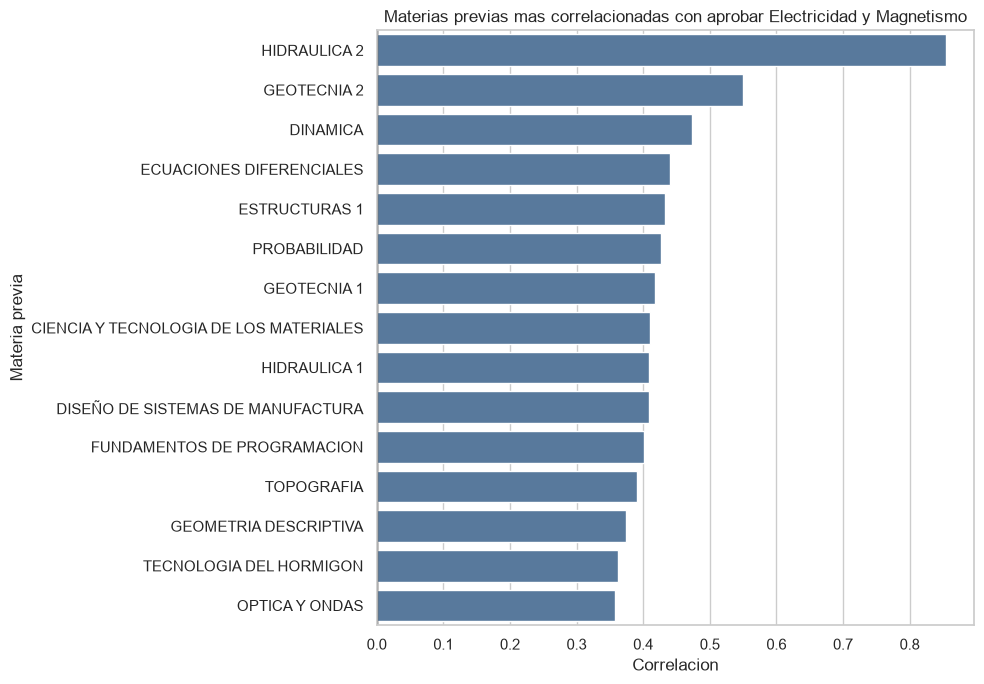

In [21]:
plt.figure(figsize=(10, 7))
plot_corr = corr_materias.head(15).copy()
sns.barplot(
    data=plot_corr,
    y="Asignatura",
    x="corr_aprobar_otra_vs_aprobar_eym",
    color="#4C78A8",
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Materias previas mas correlacionadas con aprobar Electricidad y Magnetismo")
plt.xlabel("Correlacion")
plt.ylabel("Materia previa")
plt.tight_layout()
plt.show()

## 9. Correlacion con otras materias por carrera

Aqui se repite el analisis anterior dentro de cada carrera. Esto responde si la relacion entre otras materias y Electricidad y Magnetismo cambia segun la carrera del estudiante.

In [22]:
rows_by_career = []

for (career, subject), group in corr_base.groupby(["Carrera_EyM", "Asignatura_Normalizada"]):
    rows_by_career.append({
        "Carrera_EyM": career,
        "Asignatura": subject,
        "n": len(group),
        "corr_aprobar_otra_vs_aprobar_eym": safe_corr(group["Target_Otra"], group["Target_EyM"], min_n=10),
        "corr_score_otra_vs_aprobar_eym": safe_corr(group["Score_Parciales_Otra"], group["Target_EyM"], method="spearman", min_n=10),
    })

corr_carrera_materia = (
    pd.DataFrame(rows_by_career)
    .dropna(subset=["corr_aprobar_otra_vs_aprobar_eym"], how="all")
    .sort_values(["Carrera_EyM", "corr_aprobar_otra_vs_aprobar_eym"], ascending=[True, False])
)

display(corr_carrera_materia.head(30).round(4))

mejores_por_carrera = (
    corr_carrera_materia
    .sort_values("corr_aprobar_otra_vs_aprobar_eym", ascending=False)
    .groupby("Carrera_EyM")
    .head(5)
)

display(mejores_por_carrera.round(4))

,Carrera_EyM,Asignatura,n,corr_aprobar_otra_vs_aprobar_eym,corr_score_otra_vs_aprobar_eym
44,Ing. Civil,HIDRAULICA 2,26,0.8539,0.6607
42,Ing. Civil,GEOTECNIA 2,32,0.6299,0.4737
20,Ing. Civil,ECUACIONES DIFERENCIALES,158,0.4866,0.4373
41,Ing. Civil,GEOTECNIA 1,46,0.4773,0.4860
19,Ing. Civil,DINAMICA,156,0.4350,0.4992
26,Ing. Civil,ESTRUCTURAS 1,24,0.4264,0.0440
43,Ing. Civil,HIDRAULICA 1,52,0.4090,0.4105
61,Ing. Civil,PROBABILIDAD,186,0.4055,0.3349
39,Ing. Civil,GEOMETRIA DESCRIPTIVA,124,0.4024,0.2856
70,Ing. Civil,TOPOGRAFIA,98,0.3989,0.1580


,Carrera_EyM,Asignatura,n,corr_aprobar_otra_vs_aprobar_eym,corr_score_otra_vs_aprobar_eym
352,Ing. Mecatronica,ESTADISTICA,18,1.0000,0.7303
372,Ing. Mecatronica,PROBABILIDAD,34,0.8827,0.5127
44,Ing. Civil,HIDRAULICA 2,26,0.8539,0.6607
343,Ing. Mecatronica,ANALISIS VECTORIAL,24,0.8452,0.7242
288,Ing. Industrial,METODOS NUMERICOS,28,0.7817,0.4328
78,Ing. Electromecanica,ALGEBRA LINEAL,12,0.7071,0.8281
258,Ing. Industrial,DIBUJO TECNICO,10,0.6667,0.5774
96,Ing. Electromecanica,FUNDAMENTOS DE PROGRAMACION,10,0.6667,0.8885
227,Ing. Geografica,PROBABILIDAD,16,0.6547,0.5774
42,Ing. Civil,GEOTECNIA 2,32,0.6299,0.4737


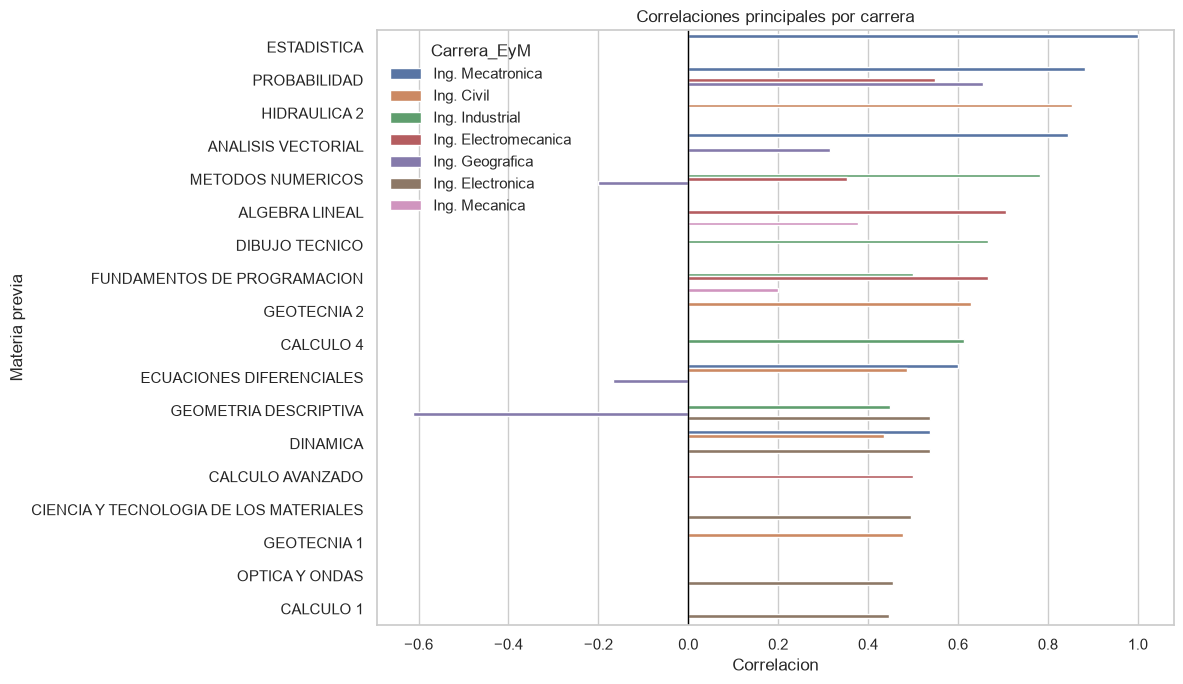

In [23]:
if not mejores_por_carrera.empty:
    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=mejores_por_carrera,
        y="Asignatura",
        x="corr_aprobar_otra_vs_aprobar_eym",
        hue="Carrera_EyM",
    )
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Correlaciones principales por carrera")
    plt.xlabel("Correlacion")
    plt.ylabel("Materia previa")
    plt.tight_layout()
    plt.show()

## 10. Sistema de alerta despues del primer parcial

Con la probabilidad estimada por la regresion logistica se puede construir una alerta temprana. La idea no es decidir automaticamente, sino priorizar estudiantes que podrian necesitar apoyo academico.

In [24]:
alertas = X_test.copy()
alertas["ALUMNO_ID"] = model_data.loc[X_test.index, "ALUMNO_ID"].values
alertas["Aprobado_Real"] = y_test.values
alertas["Proba_Aprobacion"] = y_proba_test
alertas["Proba_Riesgo"] = 1 - alertas["Proba_Aprobacion"]
alertas["Prediccion_Aprueba"] = y_pred_test
alertas["Nivel_Riesgo"] = pd.cut(
    alertas["Proba_Riesgo"],
    bins=[-0.01, 0.35, 0.65, 1.0],
    labels=["bajo", "medio", "alto"],
)

columnas_alerta = [
    "ALUMNO_ID",
    "Carrera_Nombre",
    "Primer_Par_Clean",
    "Hist_Tasa_Aprobacion",
    "Hist_Primer_Par_Mean",
    "Carga_Materias_Periodo",
    "Dificultad_Asignatura_Previa",
    "Proba_Aprobacion",
    "Proba_Riesgo",
    "Nivel_Riesgo",
    "Aprobado_Real",
]

display(alertas[columnas_alerta].sort_values("Proba_Riesgo", ascending=False).head(20))

,ALUMNO_ID,Carrera_Nombre,Primer_Par_Clean,Hist_Tasa_Aprobacion,Hist_Primer_Par_Mean,Carga_Materias_Periodo,Dificultad_Asignatura_Previa,Proba_Aprobacion,Proba_Riesgo,Nivel_Riesgo,Aprobado_Real
1066,FIUNA_ALUMNO_011761,Ing. Industrial,0,0.125000,17.125000,5,0.833611,1.373314e-08,1.000000,alto,0
1266,FIUNA_ALUMNO_010259,Ing. Electronica,0,0.375000,26.875000,6,0.833611,1.615886e-08,1.000000,alto,0
700,FIUNA_ALUMNO_007390,Ing. Electronica,6,0.000000,0.375000,4,0.833611,1.926204e-08,1.000000,alto,0
671,FIUNA_ALUMNO_006146,Ing. Civil,0,0.000000,21.200000,5,0.833611,2.482063e-08,1.000000,alto,0
1036,FIUNA_ALUMNO_010058,Ing. Mecatronica,0,0.333333,27.666667,7,0.833611,4.177617e-08,1.000000,alto,0
1312,FIUNA_ALUMNO_006701,Ing. Industrial,0,0.266667,25.666667,7,0.833611,4.462406e-08,1.000000,alto,0
978,FIUNA_ALUMNO_010664,Ing. Electronica,0,0.000000,20.125000,4,0.833611,4.689324e-08,1.000000,alto,0
1051,FIUNA_ALUMNO_010066,Ing. Industrial,0,0.500000,29.300000,5,0.833611,5.473289e-08,1.000000,alto,0
807,FIUNA_ALUMNO_005098,Ing. Civil,0,0.500000,40.833333,6,0.833611,2.801146e-07,1.000000,alto,0
710,FIUNA_ALUMNO_011264,Ing. Civil,0,0.555556,47.111111,5,0.833611,3.001069e-07,1.000000,alto,0


## Respuestas finales para el informe

**Problema abordado:** se analizo el rendimiento academico en Electricidad y Magnetismo, buscando predecir despues del primer parcial si el estudiante aprueba o no aprueba, y comparando resultados por carrera y por materias relacionadas.

**Tipo de problema:** clasificacion binaria supervisada, porque la variable objetivo tiene dos clases: aprueba (`1`) o no aprueba (`0`). Tambien se incluyo analisis exploratorio y correlacional.

**Modelo utilizado:** regresion logistica con pipeline de preprocesamiento, imputacion, interacciones polinomiales, escalado y codificacion de variables categoricas. Se uso `GridSearchCV` para ajustar el parametro `C`.

**Metricas utilizadas:** accuracy, precision, recall, F1-score, matriz de confusion, ROC-AUC y Precision-Recall/Average Precision.

**Carrera mas afectada:** se identifica con la tabla de tasa de no aprobacion por carrera. La carrera mas afectada es la que tenga mayor `tasa_no_aprobacion`.

**Correlacion con otras materias:** se calcula usando materias cursadas en periodos anteriores. Una correlacion positiva indica que aprobar o rendir bien en esa materia previa se asocia con mayor probabilidad de aprobar Electricidad y Magnetismo. Una correlacion negativa indica asociacion inversa.

**Analisis despues del primer parcial:** se usan variables disponibles hasta ese momento, como carrera, curso, periodo, primer parcial, asistencia disponible e historial previo. No se usan segundo parcial, firma, recuperatorios ni nota final como entradas, porque ocurren despues y generarian fuga de informacion.